In [ ]:
!pip install requests


In [ ]:
!pip install requests matplotlib nltk
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
!pip install requests matplotlib nltk


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # Added to address the LookupError for "punkt_tab"


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


🤖 CryptoBuddy: Hi! I’m your AI-powered crypto sidekick!
Ask about trending coins, sustainability, or price charts!
Type 'exit' to leave. ⚠️ Crypto is risky—always do your own research!

CryptoBuddy: Trending cryptos today: Tether, TRON 📈



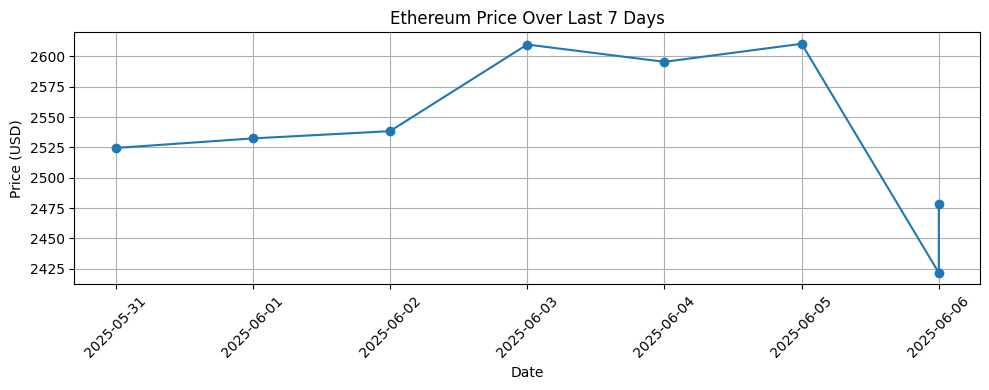

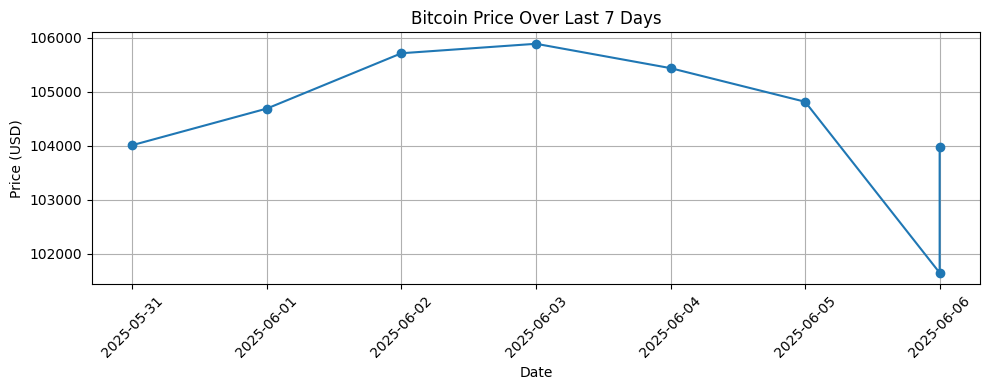

KeyboardInterrupt: Interrupted by user

In [13]:
import requests
import matplotlib.pyplot as plt
from datetime import datetime
import nltk
from nltk.tokenize import word_tokenize

# Ensure necessary NLTK data packages are downloaded
nltk.download('punkt')
nltk.download('punkt_tab')  # In case the tokenization requires this resource

# === CoinGecko API: Get Top 10 Coins === #
def fetch_top_coins():
    url = "https://api.coingecko.com/api/v3/coins/markets"
    params = {
        "vs_currency": "usd",
        "order": "market_cap_desc",
        "per_page": 10,
        "page": 1,
        "sparkline": "false"
    }
    response = requests.get(url, params=params)
    return response.json() if response.status_code == 200 else []

# === CoinGecko API: Get Historical Price Data for Plotting === #
def fetch_price_history(coin_id, days=7):
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        "vs_currency": "usd",
        "days": days,
        "interval": "daily"
    }
    response = requests.get(url, params=params)
    return response.json() if response.status_code == 200 else {}

# === Plotting Function === #
def show_price_graph(coin_name):
    # Map common names to CoinGecko coin IDs
    coin_map = {
        "bitcoin": "bitcoin",
        "ethereum": "ethereum",
        "cardano": "cardano"
    }
    coin_id = coin_map.get(coin_name.lower())
    if not coin_id:
        print("CryptoBuddy: Sorry, I can only show graphs for Bitcoin, Ethereum, or Cardano.")
        return

    data = fetch_price_history(coin_id)
    prices = data.get('prices', [])
    if not prices:
        print("CryptoBuddy: Couldn't fetch price data.")
        return

    dates = [datetime.fromtimestamp(p[0] / 1000).strftime('%Y-%m-%d') for p in prices]
    values = [p[1] for p in prices]

    plt.figure(figsize=(10, 4))
    plt.plot(dates, values, marker='o')
    plt.title(f"{coin_name.capitalize()} Price Over Last 7 Days")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === NLP-based Chatbot Response Function === #
def get_response(query, coin_data):
    # Tokenize the query to help understand user intent
    try:
        tokens = word_tokenize(query.lower())
    except LookupError:
        # If a lookup error occurs, attempt to download the needed resource and retry
        nltk.download('punkt_tab')
        tokens = word_tokenize(query.lower())

    # Show graph if requested
    if "graph" in tokens or "plot" in tokens or "chart" in tokens:
        for coin in ["bitcoin", "ethereum", "cardano"]:
            if coin in tokens:
                show_price_graph(coin)
                return None  # Graph is shown in a window; no text response needed
        return "CryptoBuddy: I can show charts for Bitcoin, Ethereum, or Cardano. Please specify one!"

    # Basic response rules based on keywords
    if "sustainable" in query or "eco" in query:
        return "Try Cardano (ADA)! 🌱 It's energy-efficient and built for long-term sustainability."

    if "trending" in query or "rising" in query or "up" in query:
        rising = [coin['name'] for coin in coin_data if coin.get('price_change_percentage_24h') and coin['price_change_percentage_24h'] > 0]
        if rising:
            return f"Trending cryptos today: {', '.join(rising)} 📈"
        else:
            return "CryptoBuddy: No coins are trending upward at the moment."

    if "long-term" in query or "growth" in query or ("investment" in tokens and "good" in tokens):
        strong = [coin['name'] for coin in coin_data if coin.get('market_cap_rank', 999) <= 5 and coin.get('price_change_percentage_24h', 0) > 0]
        if strong:
            return f"For long-term growth, consider: {', '.join(strong)} 🚀"
        else:
            return "CryptoBuddy: Couldn't find strong long-term picks today. Markets can be unpredictable!"

    if "energy" in query or "efficient" in query:
        return "Cardano and Algorand are known for their energy-efficient approaches. ⚡"

    if "market cap" in query:
        top = [coin['name'] for coin in coin_data[:3]]
        return f"Top market cap cryptos: {', '.join(top)} 💼"

    if "bye" in tokens or "exit" in tokens:
        return "Goodbye! Remember: Crypto is risky—always do your own research! 🚀"

    # Default response if no keyword is matched
    return "I'm not sure I understood. Try asking about trends, sustainability, or price graphs!"

# === Main Chat Loop === #
print("🤖 CryptoBuddy: Hi! I’m your AI-powered crypto sidekick!")
print("Ask about trending coins, sustainability, or price charts!")
print("Type 'exit' to leave. ⚠️ Crypto is risky—always do your own research!\n")

while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "bye"]:
        print("CryptoBuddy: Goodbye! 🚀 Stay safe and always DYOR!")
        break

    coins = fetch_top_coins()
    reply = get_response(user_input, coins)
    if reply:
        print(f"CryptoBuddy: {reply}\n")


error: src refspec Master does not match any
error: failed to push some refs to 'https://github.com/laywright/CryptoBuddy_Chatbot.git'
